In [4]:
import pandas as pd
import numpy as np

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.formula.api as smf


In [5]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [7]:
df=pd.read_csv('gdrive/My Drive/farm_data.csv')


In [8]:
df.shape

(299, 6)

In [10]:
display(df.head())
display(df.describe())


,Farm,Lot,Total Quantity,Pathogen Presence,Margin,Alphagos
0,Farm 5,11,23619,True,19668,0
1,Farm 5,55,19616,True,13816,0
2,Farm 5,158,19675,True,14848,0
3,Farm 5,268,19718,True,15448,0
4,Farm 5,10,19463,False,15337,0


,Lot,Total Quantity,Margin,Alphagos
count,299.000000,299.000000,299.000000,299.000000
mean,150.000000,27961.234114,22983.729097,0.020067
std,86.458082,7816.637206,7461.562550,0.140464
min,1.000000,15648.000000,11567.000000,0.000000
25%,75.500000,20578.000000,17614.000000,0.000000
50%,150.000000,25186.000000,20665.000000,0.000000
75%,224.500000,35183.500000,27014.500000,0.000000
max,299.000000,40547.000000,45606.000000,1.000000


In [12]:
# ── Data quality ─────────────────────────────────────────────
print("Nulls:\n", df.isnull().sum())

Nulls:
 Farm                 0
Lot                  0
Total Quantity       0
Pathogen Presence    0
Margin               0
Alphagos             0
dtype: int64


In [13]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 0


In [14]:
print("\nFarms:", df['Farm'].unique())


Farms: ['Farm 5' 'Farm 7' 'Farm 9' 'Farm 1' 'Farm 2' 'Farm 6' 'Farm 8' 'Farm 3'
 'Farm 4']


In [15]:
print("Alphagos usage:", df['Alphagos'].value_counts())

Alphagos usage: Alphagos
0    293
1      6
Name: count, dtype: int64


In [16]:
print("Pathogen Presence:", df['Pathogen Presence'].value_counts())

Pathogen Presence: Pathogen Presence
False    216
True      83
Name: count, dtype: int64


In [23]:
df.columns = df.columns.str.strip()

df["Pathogen Presence"] = df["Pathogen Presence"].astype(bool)
df["Alphagos"] = df["Alphagos"].astype(int)

df["pathogen"] = df["Pathogen Presence"].astype(int)
df["margin_per_chicken"] = df["Margin"] / df["Total Quantity"]

df.head()

,Farm,Lot,Total Quantity,Pathogen Presence,Margin,Alphagos,pathogen,margin_per_chicken
0,Farm 5,11,23619,True,19668,0,1,0.832719
1,Farm 5,55,19616,True,13816,0,1,0.704323
2,Farm 5,158,19675,True,14848,0,1,0.754663
3,Farm 5,268,19718,True,15448,0,1,0.783447
4,Farm 5,10,19463,False,15337,0,0,0.788008


In [26]:
#  Compare infected vs non-infected lots
task1_summary = df.groupby("Pathogen Presence").agg(
    number_of_lots=("Lot", "count"),
    avg_total_quantity=("Total Quantity", "mean"),
    avg_margin=("Margin", "mean"),
    avg_margin_per_chicken=("margin_per_chicken", "mean")
).reset_index()

task1_summary

,Pathogen Presence,number_of_lots,avg_total_quantity,avg_margin,avg_margin_per_chicken
0,False,216,28050.976852,23406.87500,0.840465
1,True,83,27727.686747,21882.53012,0.796345


In [36]:

# Exclude Alphagos lots for clean pathogen impact
no_alphagos = df[df["Alphagos"] == 0]

# Compare infected vs non-infected lots
task1_summary = no_alphagos.groupby("Pathogen Presence").agg(
    number_of_lots=("Lot", "count"),
    avg_total_quantity=("Total Quantity", "mean"),
    avg_margin=("Margin", "mean"),
    avg_margin_per_chicken=("margin_per_chicken", "mean")
).reset_index()

task1_summary

,Pathogen Presence,number_of_lots,avg_total_quantity,avg_margin,avg_margin_per_chicken
0,False,212,27960.905660,23418.603774,0.843235
1,True,81,27590.049383,21877.259259,0.799629


In [38]:
healthy_margin = no_alphagos[no_alphagos["Pathogen Presence"] == False]["margin_per_chicken"].mean()
infected_margin = no_alphagos[no_alphagos["Pathogen Presence"] == True]["margin_per_chicken"].mean()

loss_per_chicken = healthy_margin - infected_margin
loss_percent = loss_per_chicken / healthy_margin

print("Healthy margin per chicken:", round(healthy_margin, 4))
print("Infected margin per chicken:", round(infected_margin, 4))
print("Loss per chicken:", round(loss_per_chicken, 4))
print("Loss percentage:", round(loss_percent * 100, 2), "%")

Healthy margin per chicken: 0.8432
Infected margin per chicken: 0.7996
Loss per chicken: 0.0436
Loss percentage: 5.17 %


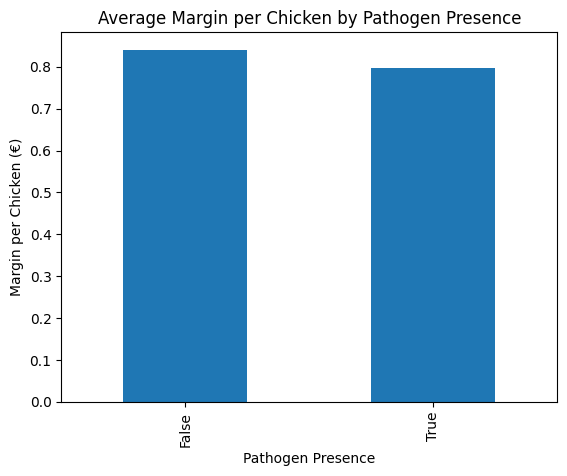

In [39]:
# Visualize the difference
import matplotlib.pyplot as plt

df.groupby("Pathogen Presence")["margin_per_chicken"].mean().plot(kind="bar")

plt.title("Average Margin per Chicken by Pathogen Presence")
plt.xlabel("Pathogen Presence")
plt.ylabel("Margin per Chicken (€)")
plt.show()

In [43]:
# Task 2: Estimate Alphagos price

antibiotic_cost_per_chicken = 0.05

# Use non-Alphagos lots
no_alphagos = df[df["Alphagos"] == 0]

infection_rate = no_alphagos["Pathogen Presence"].mean()

expected_antibiotic_cost_per_chicken = infection_rate * antibiotic_cost_per_chicken

In [44]:
print("Infection rate:", round(infection_rate * 100, 2), "%")
print("Expected antibiotic cost per chicken without Alphagos:", round(expected_antibiotic_cost_per_chicken, 4), "€")

Infection rate: 27.65 %
Expected antibiotic cost per chicken without Alphagos: 0.0138 €


In [45]:
# Suggested Alphagos price

max_break_even_price = expected_antibiotic_cost_per_chicken

suggested_low_price = max_break_even_price * 0.70
suggested_high_price = max_break_even_price * 0.85

print("Maximum break-even Alphagos price:", round(max_break_even_price, 4), "€ per chicken")
print("Suggested viable price range:", round(suggested_low_price, 4), "-", round(suggested_high_price, 4), "€ per chicken")

Maximum break-even Alphagos price: 0.0138 € per chicken
Suggested viable price range: 0.0097 - 0.0117 € per chicken
